# Decision Tree(의사결정 나무)

# Imports

In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor,plot_tree# 분류, 회귀, 나무시각화
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_validate,cross_val_score# 교차검증 수용, 교차검증점수내놔
from sklearn.metrics import mean_squared_error # 오차제곱평균

# 데이터셋

wine 데이터셋 red/white 와인 분류

In [234]:
file_path='https://bit.ly/wine_csv_data' # csv 파일이 저장된 GitHub 경로

In [235]:
wine_df=pd.read_csv(file_path)

In [236]:
wine_df[:6]

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0
5,9.4,1.8,3.51,0.0


In [237]:
# 카테고리 타입 변수 빈도수 (0- red wine, 1- white wine)
wine_df['class'].value_counts().sort_index()

,count
class,
0.0,1599
1.0,4898


In [238]:
wine_df[-6:]

,alcohol,sugar,pH,class
6491,9.7,1.3,3.29,1.0
6492,11.2,1.6,3.27,1.0
6493,9.6,8.0,3.15,1.0
6494,9.4,1.2,2.99,1.0
6495,12.8,1.1,3.34,1.0
6496,11.8,0.8,3.26,1.0


In [239]:
wine_df.describe() # 연속형(숫자,수치 타입) 자료 변수들의 기술 통계량
# sugar에 scaler 필요할거같다

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


## class 빈도수 막대 그래프

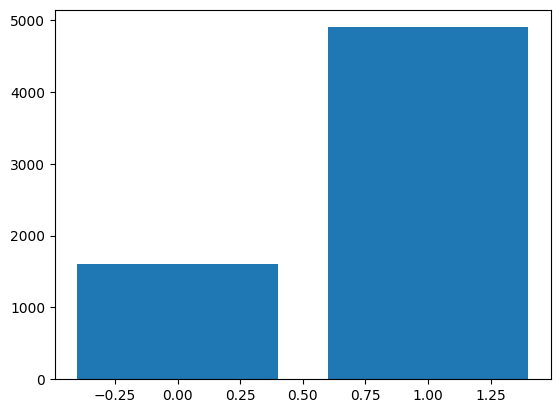

In [240]:
# plt.bar(wine_df['class'].index,wine_df['class'].values)
# plt.show()
plt.bar(wine_df['class'].value_counts().index,wine_df['class'].value_counts().values)
plt.show()

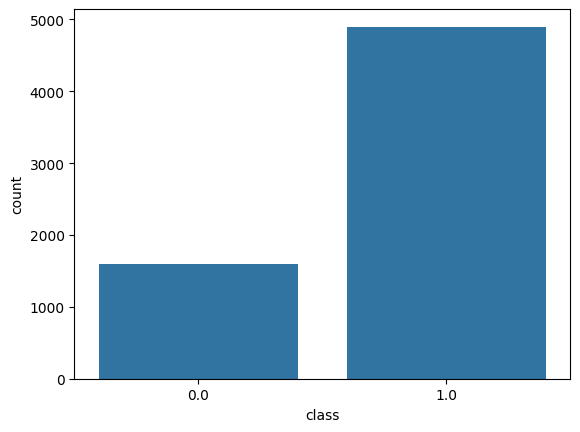

In [241]:
sns.countplot(wine_df,x='class')
plt.show()

## alcohol, sugar, pH 변수들의 히스토그램

In [242]:
# fig,axes=plt.subplots(1,3,figsize=(16,4))

# plt.hist(wine_df.alcohol.index,wine_df.alcohol.value_counts(),ax=axes[0])

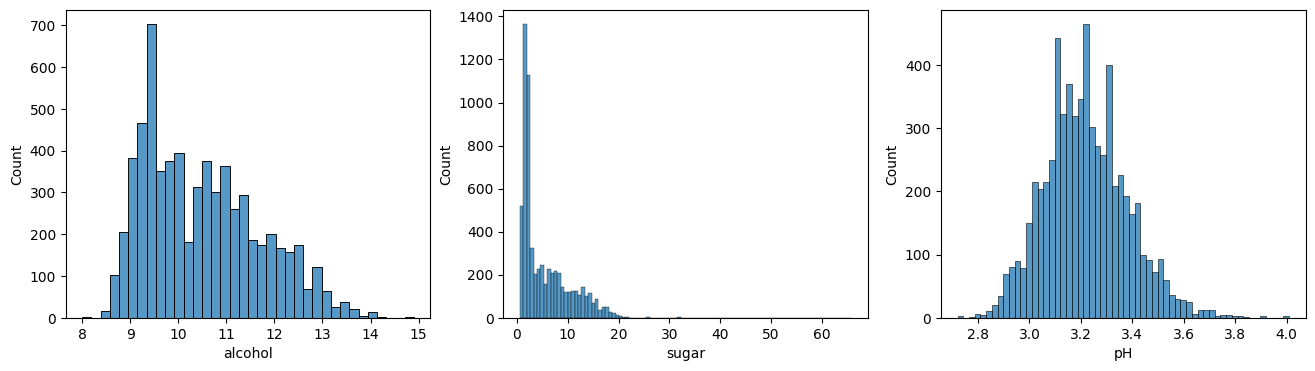

In [243]:
fig,axes=plt.subplots(1,3,figsize=(16,4))

# sns.histplot(wine_df.alcohol.index,wine_df.alcohol.value_counts(),ax=axes[0])
sns.histplot(wine_df.alcohol,ax=axes[0])
sns.histplot(wine_df.sugar,ax=axes[1])
sns.histplot(wine_df.pH,ax=axes[2])
plt.show()

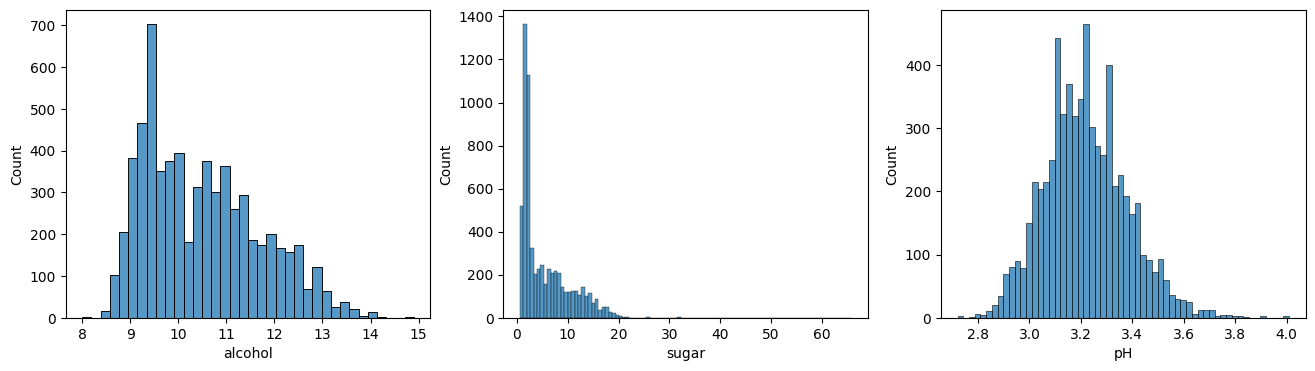

In [244]:
fig,axes=plt.subplots(1,3,figsize=(16,4))

col=wine_df.columns[:3]
for x, var in enumerate(col):
  # print(x,var)
  sns.histplot(wine_df[var],ax=axes[x])

plt.show()

## alcohol,sugar,pH 변수들의 pairplot (hue=class)

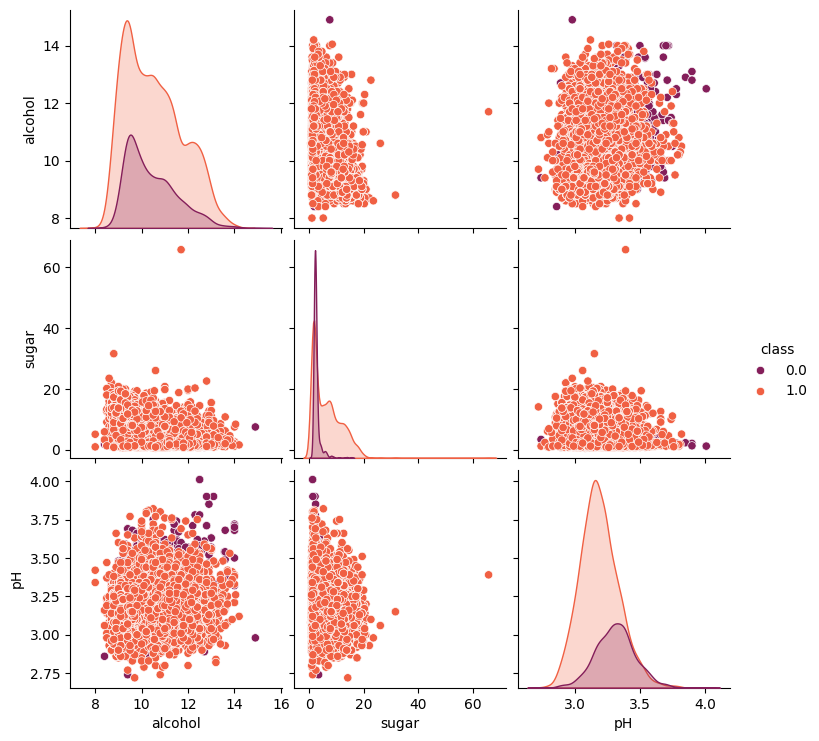

In [245]:
sns.pairplot(wine_df,hue='class',palette='rocket')
plt.show()

In [246]:
target_names = ['red', 'white']
target_names

['red', 'white']

In [247]:
feature_names=wine_df.columns[:3]#['alcohol','sugar','pH']
feature_names

Index(['alcohol', 'sugar', 'pH'], dtype='object')

# 훈련 셋, 테스트 셋 나누기

In [248]:
x=wine_df[wine_df.columns[:3]].to_numpy() # 특성 배열
y=wine_df['class'].to_numpy() # 타겟 배열

In [249]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [250]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((5197, 3), (1300, 3), (5197,), (1300,))

# Decision Tree Classifier

In [251]:
tree_clf = DecisionTreeClassifier(random_state=42) # 모델 생성

In [252]:
tree_clf.fit(x_train,y_train) # 모델 훈련

DecisionTreeClassifier(random_state=42)

In [253]:
trainpred=tree_clf.predict(x_train) # 훈련 셋 예측값
trainpred[:10]

array([1., 1., 1., 0., 0., 0., 1., 1., 1., 0.])

In [254]:
y_train[:10]

array([1., 1., 1., 0., 0., 0., 1., 1., 1., 0.])

In [255]:
cmtrain=confusion_matrix(y_train,trainpred)
cmtrain

array([[1276,    3],
       [   8, 3910]])

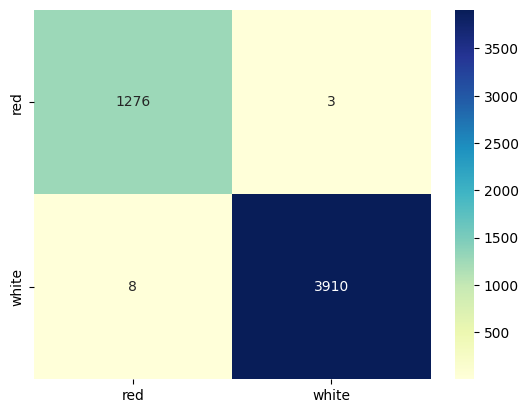

In [256]:
sns.heatmap(cmtrain,cmap='YlGnBu',annot=True,fmt='d',
            xticklabels=target_names,yticklabels=target_names)
plt.show()

In [257]:
# TP FN
# FP TN
tree_clf.score(x_train,y_train)

0.9978833942659227

In [258]:
print(classification_report(y_train,trainpred,target_names=target_names))

              precision    recall  f1-score   support

         red       0.99      1.00      1.00      1279
       white       1.00      1.00      1.00      3918

    accuracy                           1.00      5197
   macro avg       1.00      1.00      1.00      5197
weighted avg       1.00      1.00      1.00      5197



In [259]:
testpred=tree_clf.predict(x_test) # 테스트 셋 예측값
cmtest=confusion_matrix(y_test,testpred)
cmtest

array([[226,  94],
       [ 81, 899]])

In [260]:
testpred[:10]

array([0., 1., 1., 1., 1., 1., 0., 1., 1., 1.])

In [261]:
y_test[:10]

array([1., 1., 1., 1., 1., 0., 0., 1., 1., 1.])

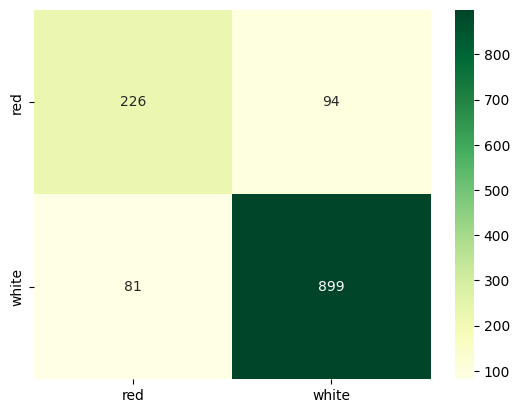

In [262]:
sns.heatmap(cmtest,cmap='YlGn',annot=True,fmt='d',
            xticklabels=target_names,yticklabels=target_names)
plt.show()

In [263]:
tree_clf.score(x_test,y_test)

0.8653846153846154

In [264]:
print(classification_report(y_test,testpred,target_names=target_names))

              precision    recall  f1-score   support

         red       0.74      0.71      0.72       320
       white       0.91      0.92      0.91       980

    accuracy                           0.87      1300
   macro avg       0.82      0.81      0.82      1300
weighted avg       0.86      0.87      0.86      1300



Decision Tree 분류 알고리즘은 과대적합(over-fitting)이 너무 크다!

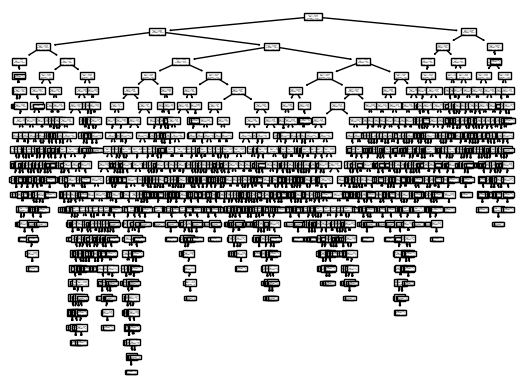

In [265]:
plot_tree(tree_clf)
plt.show()

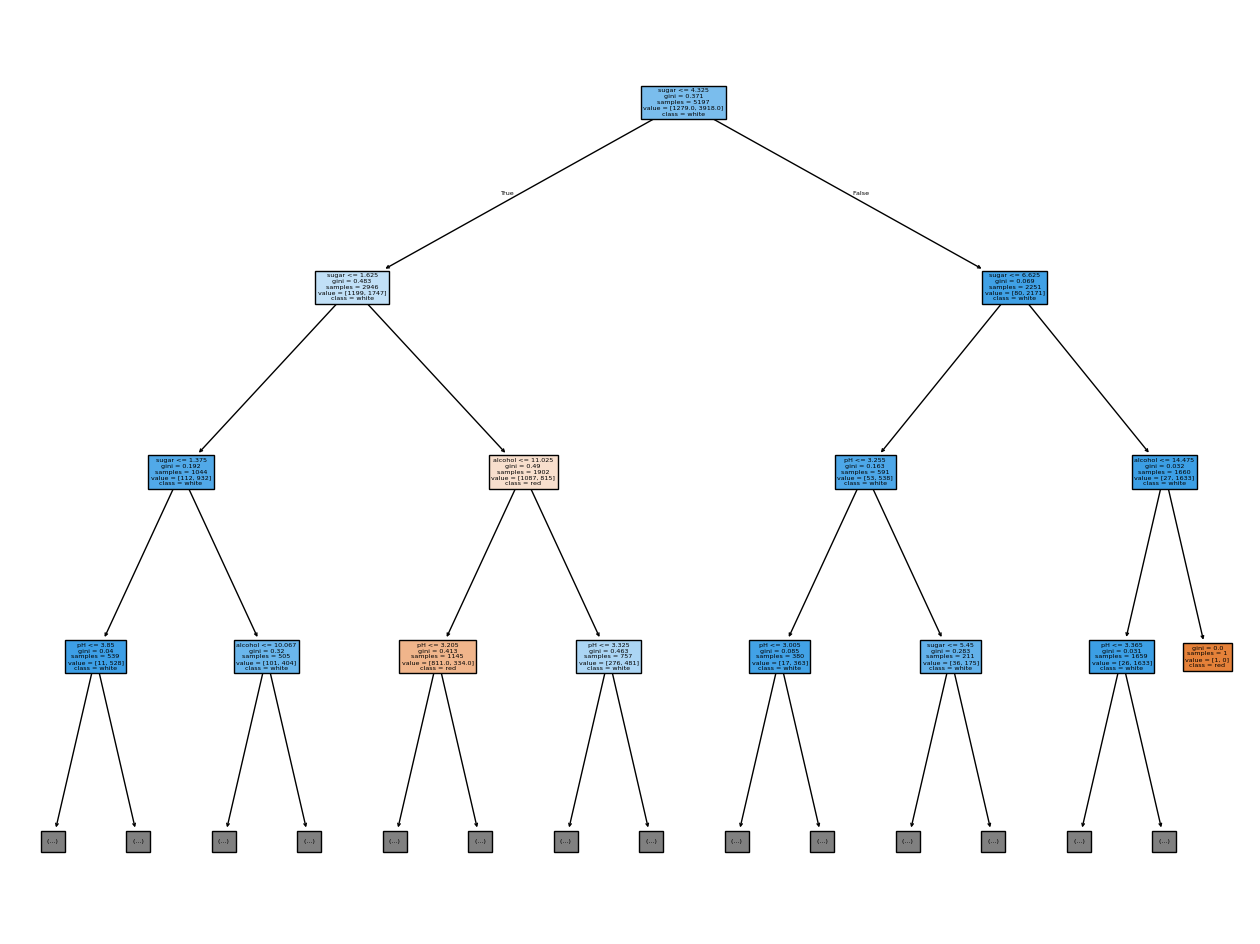

In [266]:
plt.figure(figsize=(16,12))
plot_tree(tree_clf,max_depth=3,feature_names=feature_names, class_names=target_names,
          filled=True)

plt.show()

Decision Tree를 나누는 기준

---
**Gini impurity(지니 불순도)**

$$
Gini = 1 - \sum_i p_i^2
$$

* $ p_i $: i 번째 클래스가 될 확률
* 이진(binary-class) 분류 = 최대 0.5, 최소 0
    * $ Gini = 1 - (p_0^2+p_1^2)$
    * 양성(positive) 또는 음성(negative)으로 완벽하게 분류가 된 경우, $ Gini =1 - 1=0 $
        * 예) 10개 - 10:0=1, 0:10=1
        * 불순도 최소(항상 0)
    * 양성과 음성이 똑같은 비율로 섞여 있는 경우, $ Gini = 1-(0.5^2+0.5^2)=0.5$
        * 예) 10개 - 5:5=0.5
        * 불순도 최대(항의 개수에따라 값달라짐)    
    * 양성과 음성의 비율이 6:4인 경우, $$ Gini = 1 - (0.6^2+0.4^2) = 0.48
---

**Entropy(엔트로피)**

$$
Entropy = -\sum_i p_i \log_k (p_i)
$$

*   $k$: 클래스의 개수(이진 분류인 경우, k=2),(클래스개수상관없다).
*   $p_i$: $i$번째 클래스가 될 확률.
*   이진 분류
    *   양성과 음성의 비율이 1:1인 경우, Entropy = 1. 엔트로피 (항상)최대.
    *   양성 또는 음성으로 완벽히 분류된 경우, Entropy = 0. 엔트로피 (항상)최소.
*   Decision tree 객체를 생성할 때 criterion='entropy'라고 설정하면, 부모 노드와 자식 노드에서의 엔트로피 차이가 가능하면 커지도록 가지를 생성함.

---

**Decision Tree 특징**

*   장점:
    *   특성들을 스케일링할 필요가 없다.
    *   결과를 이해하기 쉽다.
*   단점:
    *   과적합(overfitting)되기가 쉽다.
    *   여러가지 규제들을 적용해서 과적합 문제를 해결해야 함.
*   규제 하이퍼 파라미터(hyperparameter) - 생성자의 파라미터들
    *   `max_depth`: decision tree의 최대 깊이.
    *   `max_leaf_node`: leaf node의 최댓값.
    *   `max_features`: 각 노드에서 분할에 사용할 특성의 최대 개수.
    *   `min_samples_split`: 노드가 분할되기 위해서 가져야 할 최소 샘플 개수.
        * 값을키우면 딱 거기까지라서 더 분할되지 않는다 그러면 트리크기 작아짐
    *   `min_samples_leaf`: leaf 노드가 가져야 할 최소 샘플 개수.
    *   `max_`로 시작하는 파라미터의 값을 증가시키면, 트리의 크기가 커짐.
        *   규제가 작아짐.
        *   overfitting이 커짐.
    *   `max_`로 시작하는 파라미터 값을 감소시키면, 트리의 크기가 작아지기 때문에 overfitting이 작아짐.
        * 맥스를 줄이는게 규제 강화하는것
    *   `min_`으로 시작하는 파라미터 값을 증가시키면, 트리의 크기가 작아짐.    


# 하이퍼 파라미터 튜닝

max_depth의 값을 2 ~ 15까지 바꿔가면서 훈련 셋과 테스트 셋에서의 정확도를 계산하고, 시각화

In [267]:
depth=np.arange(2,16) # max_depth 파라미터로 사용할 값들
train=[] # 훈련 셋 정확도를 저장할 리스트
test=[] # 테스트 셋 정확도를 저장할 리스트
for d in depth:
  tree_clf=DecisionTreeClassifier(max_depth=d,random_state=42)
  tree_clf.fit(x_train,y_train) # 모델 훈련
  trainpred=tree_clf.predict(x_train)
  train.append(tree_clf.score(x_train,y_train)) # 훈련 셋 정확도 계산

  testpred=tree_clf.predict(x_test)
  test.append(tree_clf.score(x_test,y_test)) # 테스트 셋 정확도 계산
# 예측값은 필요없다 ML 생성, fit, score 3단계
print(train)
print(test)



[0.8062343659803733, 0.8458726188185491, 0.8595343467385029, 0.8718491437367712, 0.8778141235328074, 0.8880123147969983, 0.9003271117952665, 0.9124494900904367, 0.9255339619010968, 0.941312295555128, 0.9538195112564941, 0.9680584952857417, 0.9757552434096595, 0.9834519915335771]
[0.8107692307692308, 0.8407692307692308, 0.8523076923076923, 0.8576923076923076, 0.8484615384615385, 0.8515384615384616, 0.8584615384615385, 0.8615384615384616, 0.8615384615384616, 0.8584615384615385, 0.8646153846153846, 0.8623076923076923, 0.8661538461538462, 0.8676923076923077]


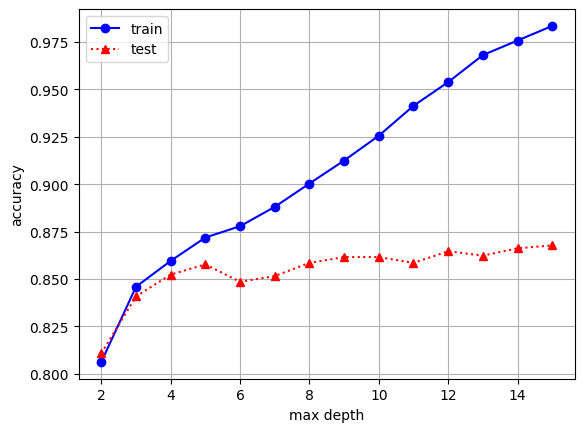

In [268]:
plt.plot(depth,train, 'bo-',label='train')
plt.plot(depth,test, 'r^:',label='test')

plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.legend()
plt.grid()
plt.show()
# 뎁스는 5가 제일 베스트?

max_depth=4 Decision Tree

In [269]:
tree_clf =DecisionTreeClassifier(max_depth=4,random_state=42)


In [270]:
tree_clf.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

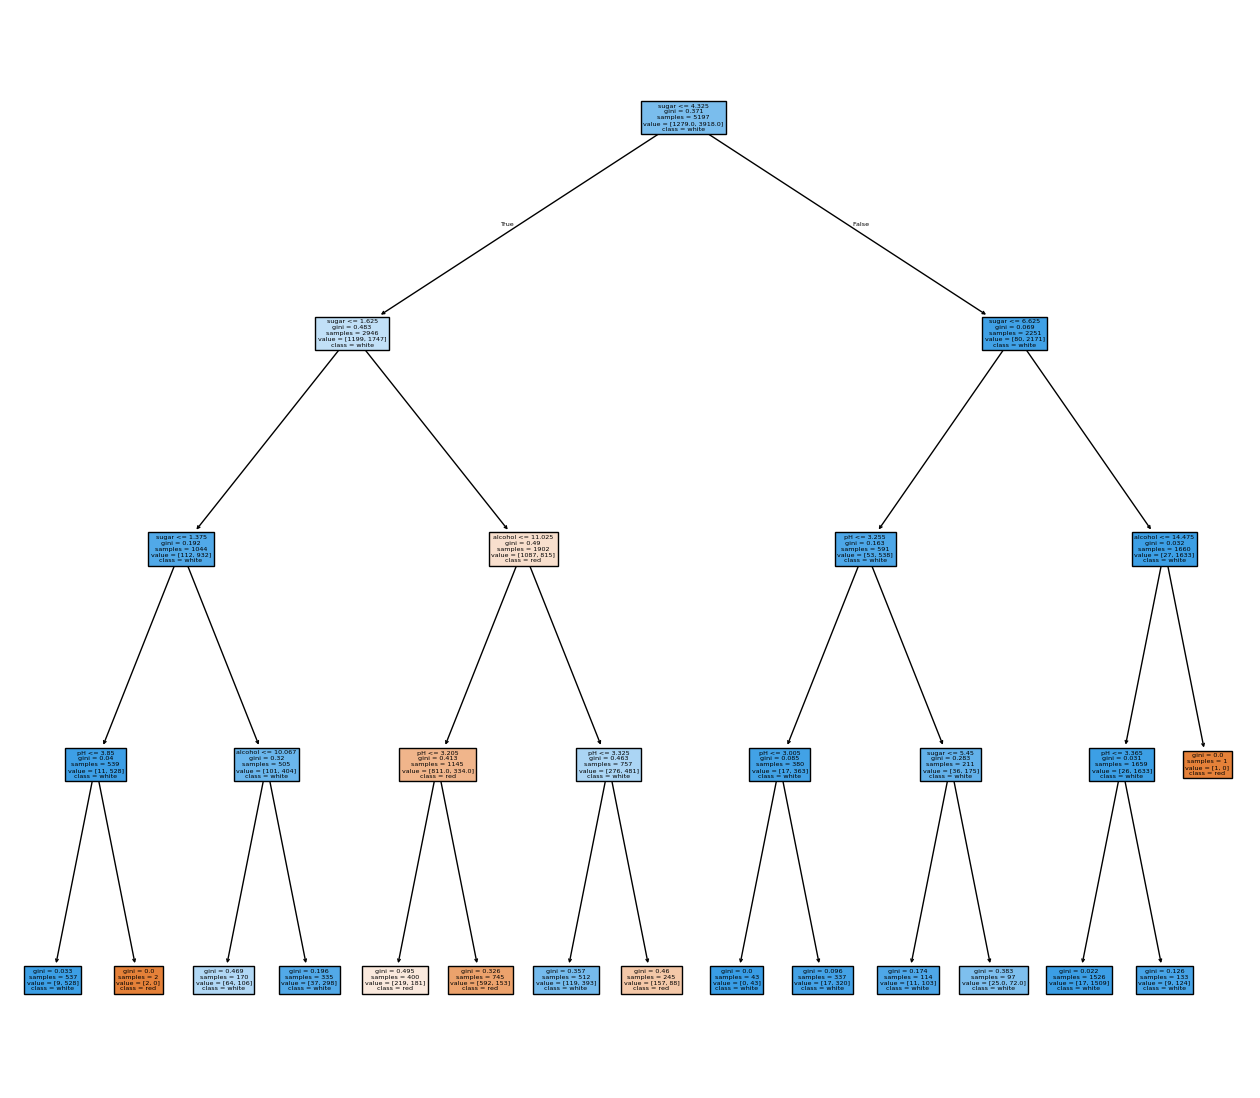

In [271]:
plt.figure(figsize=(16,14))
plot_tree(tree_clf,filled=True,feature_names=feature_names,class_names=target_names)
plt.show() # filled 색채우기,

In [272]:
print('훈련 셋 정확도:',tree_clf.score(x_train,y_train))
print('테스트 셋 정확도:',tree_clf.score(x_test,y_test))

훈련 셋 정확도: 0.8595343467385029
테스트 셋 정확도: 0.8523076923076923


In [273]:
tree_clf=DecisionTreeClassifier(max_depth=5,random_state=42)
tree_clf.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

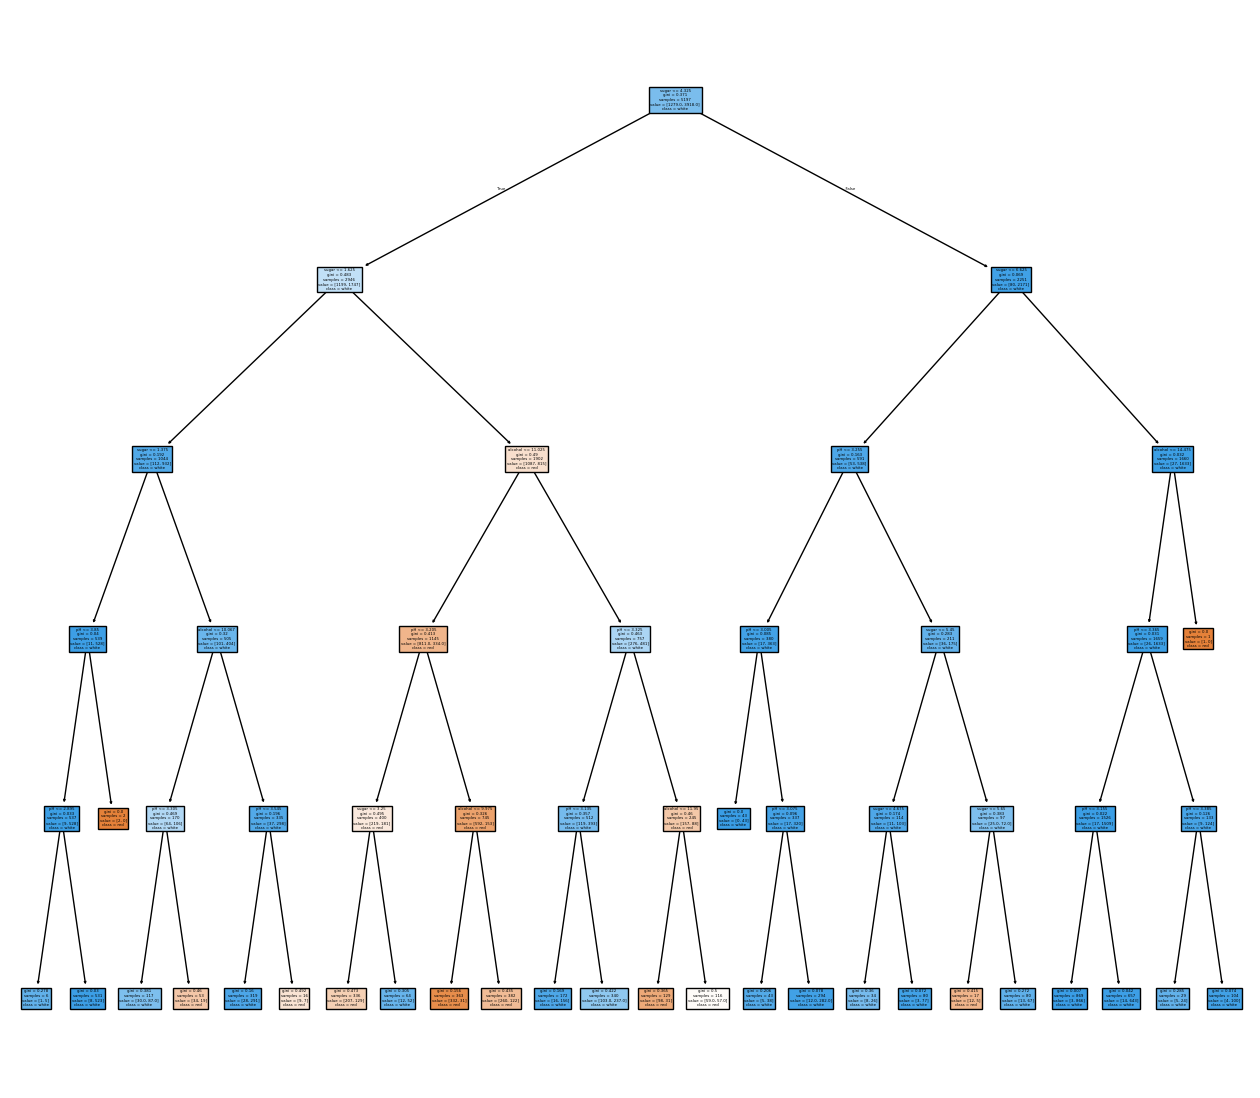

In [274]:
plt.figure(figsize=(16,14))
plot_tree(tree_clf,filled=True,feature_names=feature_names,class_names=target_names)
plt.show()

In [275]:
print('훈련 셋 정확도:',tree_clf.score(x_train,y_train))
print('테스트 셋 정확도:',tree_clf.score(x_test,y_test))

훈련 셋 정확도: 0.8718491437367712
테스트 셋 정확도: 0.8576923076923076


**하이퍼 파라미터(hyper-parameter) 튜닝**

* 전체 데이터를 훈련(train)- 검증(validation)- 테스트(test) 셋으로 나눔
* 하이퍼 파라미터를 변경하면서 훈련 셋으로 ML 모델을 훈련시킴.
* 하이퍼 파라미터 설정에 따른 성능 테스트는 검증 셋으로 수행.
  * 검증 셋에서 점수가 좋은(그리고 과대적합이 작은) 하이퍼 파라미터를 선택.
* 튜닝이 끝난 모델의 일반화 성능을 예측하기 위해서 테스트 셋을 마지막에 한 번 사용.  

## Train/Validation/Test 나누고 하이퍼 파라미터 튜닝

In [276]:
x.shape,y.shape

((6497, 3), (6497,))

In [277]:
# 전체 데이터 셋(x,y)을 훈련/테스트 셋으로 나눔.
x_tr_full, x_test, y_tr_full, y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)




In [278]:
x_tr_full.shape

(5197, 3)

In [279]:
# 전체 훈련 셋(x_tr_full,y_tr_full)을 (작은) 훈련/검증 셋으로 나눔
x_tr,x_val,y_tr,y_val=train_test_split(x_tr_full,y_tr_full,test_size=0.2,random_state=42,stratify=y_tr_full)

In [280]:
x_tr.shape,x_val.shape,x_test.shape

((4157, 3), (1040, 3), (1300, 3))

# 훈련 셋과 검증 셋으로 max_depth를 튜닝

In [281]:
train_scores=[]
validation_scores=[]
max_depths=np.arange(2,16)
for d in max_depths:
  tree_clf=DecisionTreeClassifier(max_depth=d,random_state=42)
  tree_clf.fit(x_tr,y_tr)
  train_scores.append(tree_clf.score(x_tr,y_tr))
  val_acc=tree_clf.score(x_val,y_val)
  validation_scores.append(val_acc)
  # test_scores.append()
  # 테스트 대신에 val을 사용
  # a b
  # a1 a2
  print(train_scores)
  print(validation_scores)

[0.8270387298532595]
[0.8298076923076924]
[0.8270387298532595, 0.8272792879480394]
[0.8298076923076924, 0.8298076923076924]
[0.8270387298532595, 0.8272792879480394, 0.8636035602598028]
[0.8298076923076924, 0.8298076923076924, 0.864423076923077]
[0.8270387298532595, 0.8272792879480394, 0.8636035602598028, 0.8691363964397402]
[0.8298076923076924, 0.8298076923076924, 0.864423076923077, 0.875]
[0.8270387298532595, 0.8272792879480394, 0.8636035602598028, 0.8691363964397402, 0.8775559297570363]
[0.8298076923076924, 0.8298076923076924, 0.864423076923077, 0.875, 0.8682692307692308]
[0.8270387298532595, 0.8272792879480394, 0.8636035602598028, 0.8691363964397402, 0.8775559297570363, 0.8888621602116912]
[0.8298076923076924, 0.8298076923076924, 0.864423076923077, 0.875, 0.8682692307692308, 0.8615384615384616]
[0.8270387298532595, 0.8272792879480394, 0.8636035602598028, 0.8691363964397402, 0.8775559297570363, 0.8888621602116912, 0.8987250420976666]
[0.8298076923076924, 0.8298076923076924, 0.8644230

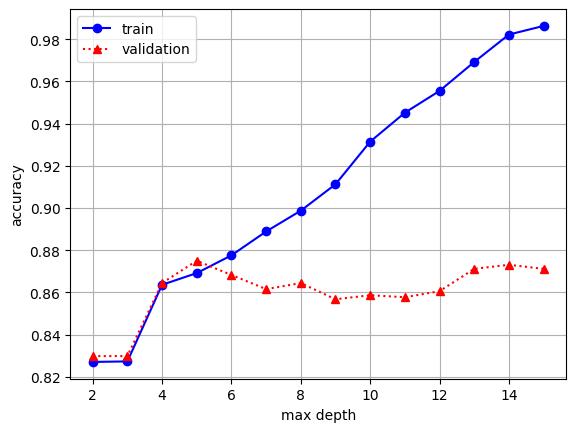

In [282]:
plt.plot(max_depths,train_scores,'bo-',label='train')
plt.plot(max_depths,validation_scores,'r^:',label='validation')

plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.grid()
plt.legend()
plt.show()

훈련/검증 셋을 사용해서 `min_samples_split` 파라미터튜닝

In [283]:
train=[]
vali=[]
# minsam=np.arange(2,150)
minsam=np.arange(0.0005,0.125,0.0005)
for m in minsam:
  tree_clf=DecisionTreeClassifier(min_samples_split=m,random_state=42)
  tree_clf.fit(x_tr,y_tr)
  train.append(tree_clf.score(x_tr,y_tr))
  vali.append(tree_clf.score(x_val,y_val))


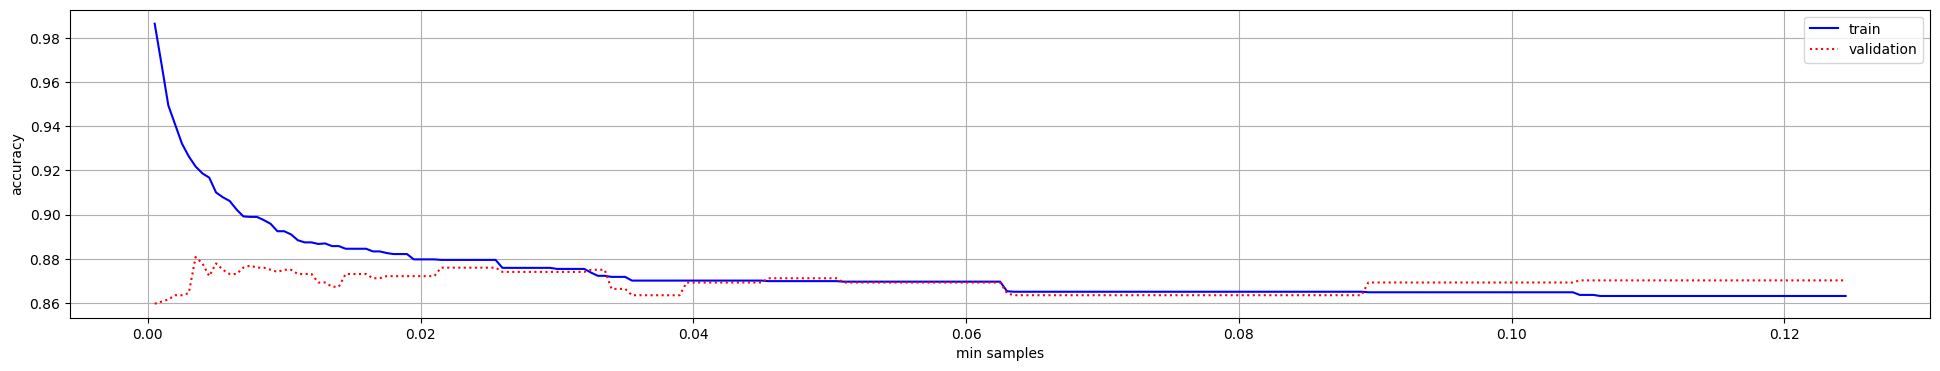

In [284]:
plt.figure(figsize=(24,4))
plt.plot(minsam,train,'b-',label='train')
plt.plot(minsam,vali,'r:',label='validation')

plt.xlabel('min samples')
plt.ylabel('accuracy')
plt.grid()
plt.legend()
plt.show()

# 교차 검증 (Cross Validation)

**n-ford 교차검증(CV)**

* 전체 훈련 셋을 n개의 파티션으로 나눠서 (n-1)개는 훈련할 때 사용하고, 1개는 검증용으로 사용.
* 검증용 세트를 바꿔가면서 n번 훈련/검증을 반복.
* n개의 훈련 셋 점수를 평균, n개의 검증 셋 점수를 평균.


In [285]:
# 교차검증에서 사용할 ML 모델 생성(Decision Tree, max_depth=5)
clf= DecisionTreeClassifier(max_depth=5,random_state=42)

# n-ford 훈련셋을 n개로 구분해서 교차검증실시
# 5-fold CV: 전체 훈련 셋을 5개로 나누고 그 중 한 개를 검증 셋으로 사용.
# estimator 파라미터: 예측기, ML모델 객체.
# x,y: 훈련셋, 훈련레이블
# cv: n-ford cv에서 n값.
# n_jobs: 동시에(병렬로) 수행할 작업 개수. 기본값은 1. -1인 경우에는 CPU의 모든 코어를 사용.
# return_train_score: 훈련 점수를 리턴할지 여부.
cv=cross_validate(clf,x_tr_full,y_tr_full,cv=5,n_jobs=-1,return_train_score=True)

In [286]:
cv # dict(key-value)

{'fit_time': array([0.00993919, 0.00957584, 0.00913525, 0.00892854, 0.00669193]),
 'score_time': array([0.00417137, 0.00243998, 0.00174856, 0.00178885, 0.00123644]),
 'test_score': array([0.88173077, 0.86538462, 0.84600577, 0.86910491, 0.85370549]),
 'train_score': array([0.86817416, 0.8708203 , 0.87662338, 0.87638288, 0.87469937])}

In [287]:
# 각각의 교차검증에서 검증 셋의 정확도 평균
np.mean(cv['test_score'])

np.float64(0.8631863108018065)

In [288]:
# 각각의 교차검증에서 훈련 셋의 정확도 평균
np.mean(cv['train_score'])
# 교차검증에서 훈련 셋 정확도 평균은 교차검증을 하지 않은 경우와 비슷하거나 약간 좋음.

np.float64(0.8733400189738896)

In [289]:
# n-ford CV에서 각각의 검증 셋에서의 점수(정확도)들의 배열을 리턴.
cross_val_score(estimator=clf,X=x_tr_full,y=y_tr_full,cv=5,n_jobs=-1) # test_score

array([0.88173077, 0.86538462, 0.84600577, 0.86910491, 0.85370549])

## 교차 검증을 사용한 max_depth 하이퍼 파라미터튜닝

In [290]:
train=[]
test=[]
# std=[]
depth=np.arange(2,16)
for d in depth:
  clf=DecisionTreeClassifier(max_depth=d,random_state=42)
  cv=cross_validate(clf,x_tr_full,y_tr_full,cv=5,n_jobs=-1,return_train_score=True)
  train.append(np.mean(cv['train_score'])) # 5-ford cv에서 5개의 훈련 점수들의 평균으로 측정
  test.append(np.mean(cv['test_score'])) # 5-ford cv에서 5개의 검증 점수들의 평균
  # std.append(np.std(cv['test_score']))


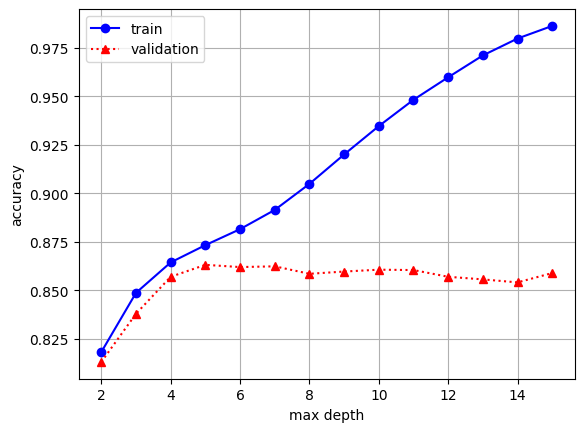

In [291]:
plt.plot(depth,train, 'bo-',label='train')
plt.plot(depth,test,'r^:',label='validation')
# plt.plot(depth,std)
plt.legend()
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.grid()
plt.show()

## 교차 검증(CV)에서 가장 좋은 검증(테스트) 점수와 그때의 하이퍼 파라미터 찾기

In [292]:
np.max(test) # 배열(리스트)의 최댓값

np.float64(0.8631863108018065)

In [293]:
idx=np.argmax(test) # 배열(리스트)의 최댓값의 인덱스 0 1 2 3
idx #argmax로 위치찾고

np.int64(3)

In [294]:
depth[idx] # depth의 몇번째 값이 최고
# 검증 셋 점수가 최대가 되는 max_depth 값.

np.int64(5)

## Grid Search CV

여러 개의 하이퍼 파라미터들의 조합에서 최적의 파라미터 조합을 찾는 과정.

In [295]:
# 하이퍼 파라미터 튜닝에 사용할 ML모델(예측기, estimator) 생성
clf = DecisionTreeClassifier(random_state=42)


In [296]:
# 튜닝할 파라미터들의 조합(grid)을 dict로 만듦. 키는 ML 클래스 나무의 파라미터 이름을 사용.
params = {
    'max_depth':np.arange(2,21),
    'min_samples_split': np.arange(2,101,2)
}

In [297]:
# GridSearchCV 객체 생성
grid_cv = GridSearchCV(estimator=clf, param_grid=params, n_jobs=-1)

In [298]:
# GridSearchCV 실행,수행(훈련)한다
grid_cv.fit(x_tr_full,y_tr_full)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20]),
                         'min_samples_split': array([  2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,  26,
        28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,  52,
        54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,  78,
        80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100])})

In [299]:
grid_cv.best_score_ # 교차 점증에서 'test_score'(검증점수)의 최댓값

np.float64(0.867805767379877)

In [300]:
grid_cv.best_params_ # 교차 검증에서 'test_score'를 최대로 만들어 주는 파라미터 조합


{'max_depth': np.int64(7), 'min_samples_split': np.int64(84)}

In [301]:
grid_cv.best_estimator_ # 교차 검증에서 'test_score'가 최대인 최적인 ML 모델

DecisionTreeClassifier(max_depth=np.int64(7), min_samples_split=np.int64(84),
                       random_state=42)

# Random Search Cross Validation

* Grid Search CV는 파라미터들의 조합을 직접 (dict 타입으로) 만들어서 CV를 수행.
* Random Search CV
  * 하이퍼 파라미터들의 조합을 난수로 만들 수 있도록 확률 분포 객체를 생성.
    * scipy 패키지의 확률 분포 함수들을 이용.
  * CV를 수행하는 객체가 파라미터들을 특정 확률 분포를 따르는 난수로 생성해서 CV를 수행.

In [302]:
# [0,10) 범위의 정수들을 균등분포로 만들어 주는 확률 분포 객체.
int_gen = scipy.stats.randint(0,10)
int_gen # 난수 발생기

In [303]:
numbers= int_gen.rvs(10) # 난수 발생기로 난수를 10개 생성.
numbers       # rvs=random values

array([3, 3, 5, 7, 7, 1, 0, 1, 0, 6])

In [304]:
np.unique(numbers,return_counts=True)
# 앞 유니크값, 뒤 유니크값이 나온 횟수

(array([0, 1, 3, 5, 6, 7]), array([2, 2, 2, 1, 1, 2]))

In [305]:
# [0,10) 난수발생기로 100개 생성
numbers= int_gen.rvs(100)
numbers

array([8, 0, 0, 5, 6, 9, 2, 3, 5, 4, 1, 2, 0, 1, 9, 6, 0, 8, 4, 4, 0, 0,
       6, 1, 3, 1, 8, 0, 9, 5, 9, 6, 3, 6, 4, 2, 5, 5, 0, 3, 8, 6, 8, 5,
       6, 3, 9, 4, 7, 9, 7, 8, 6, 3, 9, 4, 8, 7, 3, 0, 8, 1, 0, 6, 3, 6,
       4, 8, 4, 7, 5, 1, 8, 4, 3, 9, 8, 9, 4, 0, 2, 4, 3, 7, 7, 3, 6, 6,
       3, 2, 8, 3, 5, 6, 2, 4, 1, 4, 5, 2])

## `scipy.stats` 모듈 난수 발생기

In [306]:
np.unique(numbers, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([11,  7,  7, 13, 13,  9, 13,  6, 12,  9]))

In [307]:
numbers=int_gen.rvs(1000)
np.unique(numbers,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([ 94,  99,  89, 105, 122,  95,  96,  91, 109, 100]))

In [308]:
# [0,1) 범위의 실수들을 균등 분포로 만들어 주는 난수 발생기
num_gen = scipy.stats.uniform(0,1)

In [309]:
num_gen.rvs(10) # 실수 난수 10개 생성

array([0.45513661, 0.65560536, 0.46286166, 0.51401872, 0.88205166,
       0.38911789, 0.78142597, 0.78875743, 0.66786111, 0.01188481])

## Random Search CV

In [310]:
x_tr_full

array([[ 9.4 , 11.2 ,  3.19],
       [11.  ,  1.2 ,  3.06],
       [11.2 ,  4.8 ,  3.12],
       ...,
       [ 9.  , 14.7 ,  2.96],
       [12.7 ,  9.1 ,  3.16],
       [ 9.3 ,  7.1 ,  3.08]])

In [311]:
# ML 모델 - Decision Tree
tree_clf= DecisionTreeClassifier(random_state=42)

In [312]:
# 튜닝할 파라미터들의 조합(grid) > 난수 확률 분포
params ={
    'max_depth':scipy.stats.randint(2,100),
    'min_samples_split':scipy.stats.randint(2,500),
    'min_samples_leaf':scipy.stats.randint(2,50),
    'min_impurity_decrease':scipy.stats.uniform(0.0001, 0.001)
}

In [313]:
# RandomizedSearchCV 객체 생성
rand_cv=RandomizedSearchCV(tree_clf, param_distributions=params,
                           n_iter=100, n_jobs=-1,random_state=42)
                # 파라미터를 튜닝할 머신러닝모델, 파라미터들의 확률 분포
                # 파라미터 조합의 개수

In [314]:
# CV를 통해서 최적의 파라미터 조합을 검색하는 과정
rand_cv.fit(x_tr_full,y_tr_full)

RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79cc380c5b80>,
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79cc380c4620>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79cc380c52b0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79cc368b05f0>},
                   random_state=42)

In [315]:
rand_cv.best_params_

{'max_depth': 37,
 'min_impurity_decrease': np.float64(0.00028223608778806236),
 'min_samples_leaf': 5,
 'min_samples_split': 3}

In [316]:
rand_cv.best_score_

np.float64(0.8662656400384986)

In [317]:
rand_cv.best_estimator_# 분류 회귀다가능

DecisionTreeClassifier(max_depth=37,
                       min_impurity_decrease=np.float64(0.00028223608778806236),
                       min_samples_leaf=5, min_samples_split=3,
                       random_state=42)

# Decision Tree Regressor

결정 나무 알고리즘을 사용한 회귀(수치 예측) 모델.

## 데이터 셋 준비

white wine의 여러가지 화학적 특성 값들을 사용한 와인 품질(점수) 예측.

In [318]:
file_path='https://github.com/JakeOh/202511_BD53/raw/refs/heads/main/datasets/white_wine.csv'

In [319]:
white_wine_df=pd.read_csv(file_path,sep=';') # 값들이 콜론으로 구분됨

In [320]:
white_wine_df[:6]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6


In [321]:
white_wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [322]:
feature_names=white_wine_df.columns[:-1]# 마지막하나제외
print(feature_names)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')


In [323]:
white_wine_df.quality.unique()

array([6, 5, 7, 8, 4, 3, 9])

In [324]:
white_wine_df[white_wine_df.quality==9]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
774,9.1,0.27,0.45,10.6,0.035,28.0,124.0,0.99700,3.20,0.46,10.4,9
820,6.6,0.36,0.29,1.6,0.021,24.0,85.0,0.98965,3.41,0.61,12.4,9
827,7.4,0.24,0.36,2.0,0.031,27.0,139.0,0.99055,3.28,0.48,12.5,9
876,6.9,0.36,0.34,4.2,0.018,57.0,119.0,0.98980,3.28,0.36,12.7,9
1605,7.1,0.26,0.49,2.2,0.032,31.0,113.0,0.99030,3.37,0.42,12.9,9


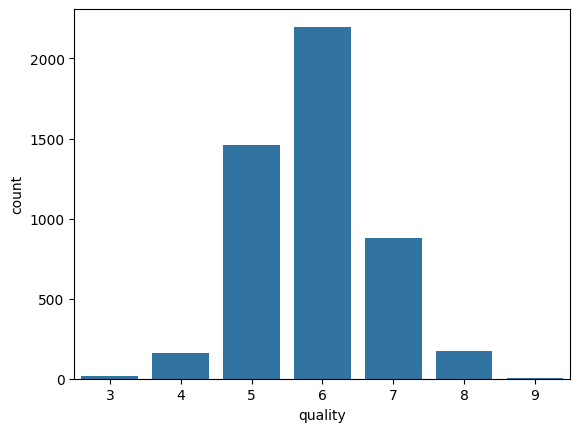

In [325]:
# white wine 품질 빈도수
sns.countplot(white_wine_df, x='quality')
plt.show()

In [326]:
white_wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [327]:
# sns.pairplot(white_wine_df)
# plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [328]:
x=white_wine_df[feature_names].to_numpy()
y=white_wine_df.quality.to_numpy()

In [329]:
x.shape, y.shape

((4898, 11), (4898,))

In [330]:
# 훈련 셋, 테스트 셋으로 나누기.
x_tr_full,x_test,y_tr_full,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# 분류X, 수치 예측문제O
# 층화추츨불필요

In [331]:
# 훈련 셋과 훈련 레이블을 다시 훈련/검증 세트로 나누기.
x_tr,x_val,y_tr,y_val=train_test_split(x_tr_full,y_tr_full,test_size=0.2,random_state=42)

In [332]:
x_tr_full.shape,x_test.shape

((3918, 11), (980, 11))

In [333]:
x_tr.shape,x_val.shape

((3134, 11), (784, 11))

## Decision Tree 훈련, 평가

In [334]:
tree_reg= DecisionTreeRegressor(random_state=42)# Decision Tree 생성

In [335]:

tree_reg.fit(x_tr,y_tr) # Decision Tree 훈련

DecisionTreeRegressor(random_state=42)

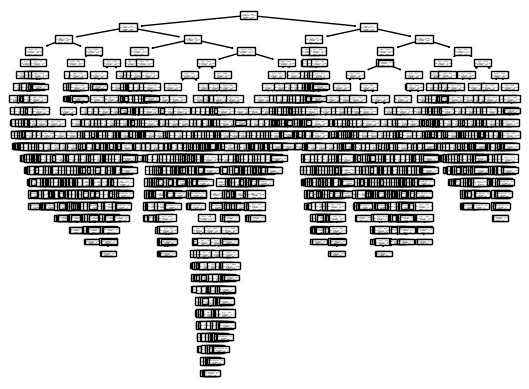

In [336]:
# plot_tree(tree_reg)
# plt.show()

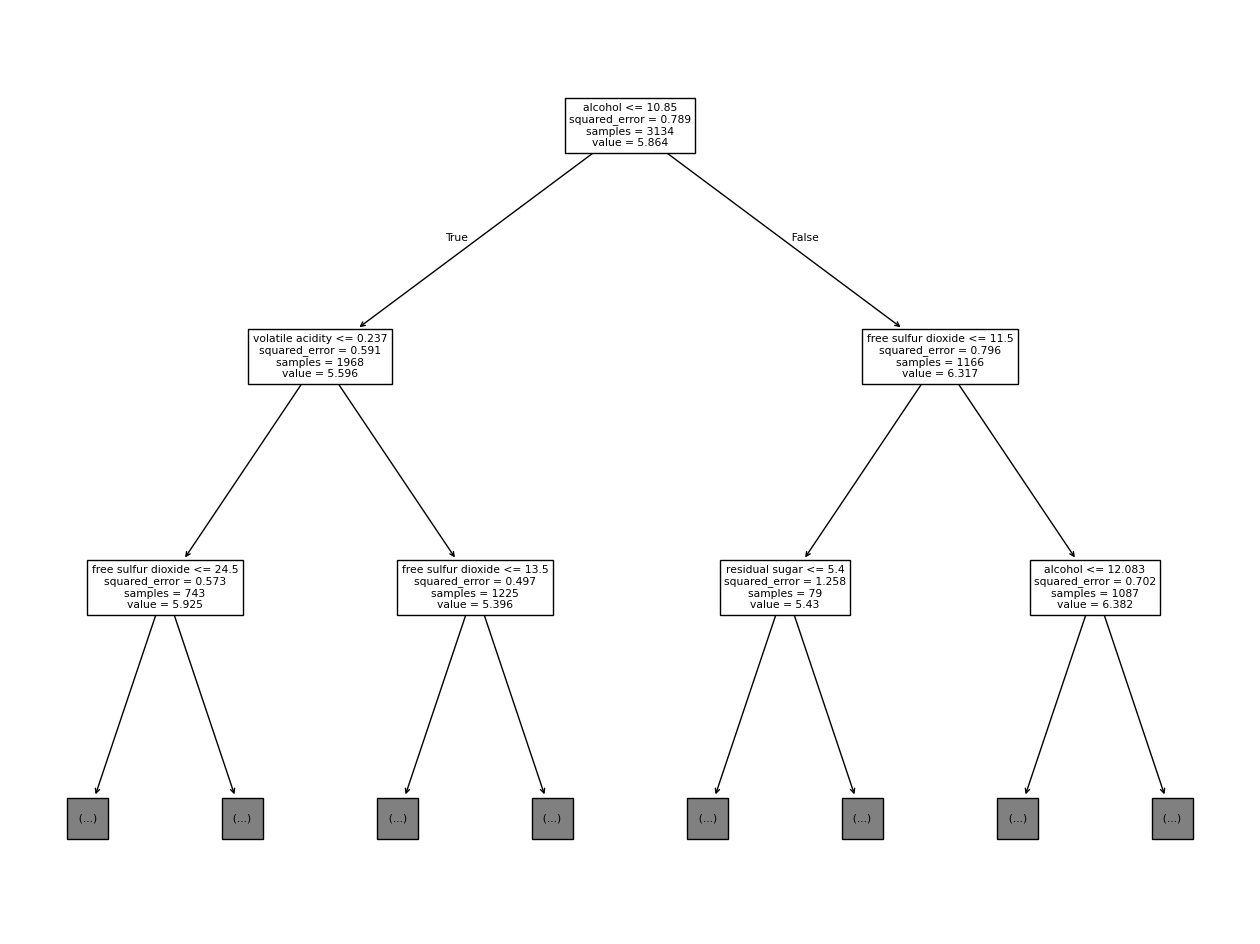

In [337]:
plt.figure(figsize=(16,12))

plot_tree(tree_reg,max_depth=2,feature_names=feature_names)
plt.show()

In [338]:
np.mean(y_tr) # 훈련 레이블(white wine 전문가 평가 점수)의 평균
# value

np.float64(5.864071474154435)

In [339]:
np.var(y_tr) # 훈련 레이블의 분산(y - y_bar)**2 > 평균
# squered error

np.float64(0.7894366458167803)

In [340]:
trainpred=tree_reg.predict(x_tr) # 훈련 셋 예측값
trainpred[:10]

array([7., 7., 6., 5., 6., 6., 7., 6., 6., 6.])

In [341]:
y_tr[:10] # 훈련 셋 실젯값

array([7, 7, 6, 5, 6, 6, 7, 6, 6, 6])

In [342]:
tree_reg.score(x_tr,y_tr) # R2 score(결정계수)

1.0

In [343]:
mean_squared_error(y_tr,trainpred)
# 결정계수와 mse는 반비례관계처럼보임 실제론 아님

0.0

In [344]:
valpred=tree_reg.predict(x_val)
valpred[:10] # 검증 셋 예측값

array([7., 6., 5., 8., 6., 6., 7., 6., 6., 8.])

In [345]:
y_val[:10] # 검증 셋의 실젯값

array([7, 7, 5, 8, 5, 6, 5, 6, 6, 8])

In [346]:
tree_reg.score(x_val,y_val) # 검증 셋 결정계수 <1 이좋다

0.03833432921235802

In [347]:
mean_squared_error(y_val,valpred) # 0이 좋다

0.7436224489795918

Decision Tree는 과대적합이 심하다.

In [348]:
tree_reg.feature_importances_ # 특성 중요도점수

array([0.05771603, 0.11060848, 0.06218407, 0.06726019, 0.06236955,
       0.13249433, 0.08662563, 0.05956508, 0.0726096 , 0.06249428,
       0.22607275])

In [350]:
idx= np.argmax(tree_reg.feature_importances_)
idx

np.int64(10)

In [351]:
feature_names[idx]

'alcohol'

In [352]:
feature_names[5] # feature_importances_에서 두번째로 큰 값의 특성 이름

'free sulfur dioxide'

In [353]:
feature_names[1] # feature_importances_에서 세번째로 큰 값의 특성 이름

'volatile acidity'

## `cross_validate` 또는 `cross_val_score` 사용해서 최적의 max_depth 찾기

In [380]:
max_depths=np.arange(2,21) # Decision Tree에서 튜닝할 max_depth 값들
train_scores=[] # CV에서 train_score의 평균값을 저장할 리스트
val_scores=[] # CV에서 test_score의 평균값을 저장할 리스트

for d in max_depths:
  tree_reg=DecisionTreeRegressor(max_depth=d,random_state=42)
  cv=cross_validate(tree_reg,x_tr_full,y_tr_full,n_jobs=-1,return_train_score=True)
  train_scores.append(np.mean(cv['train_score']))
  val_scores.append(np.mean(cv['test_score']))
print(train_scores)
print(val_scores)

[np.float64(0.2423979816672869), np.float64(0.2873868985866099), np.float64(0.33330358711959485), np.float64(0.3837066650522202), np.float64(0.44249849276479836), np.float64(0.5031711973669284), np.float64(0.5686962692180421), np.float64(0.6364908452921885), np.float64(0.7023182935086394), np.float64(0.7630048427581102), np.float64(0.8175778835749572), np.float64(0.865065104641505), np.float64(0.9027536823887301), np.float64(0.932540770792291), np.float64(0.9533099500051776), np.float64(0.9674116687275799), np.float64(0.9775342680393623), np.float64(0.9853334020529024), np.float64(0.9905841674430398)]
[np.float64(0.22749732187363284), np.float64(0.25685486268994334), np.float64(0.2582665886251677), np.float64(0.2728187073512451), np.float64(0.25426493877888434), np.float64(0.25177305708529635), np.float64(0.22945577750975593), np.float64(0.19520162451540737), np.float64(0.16428732972299434), np.float64(0.1453902153889746), np.float64(0.1004630972276321), np.float64(0.06588694695517386)

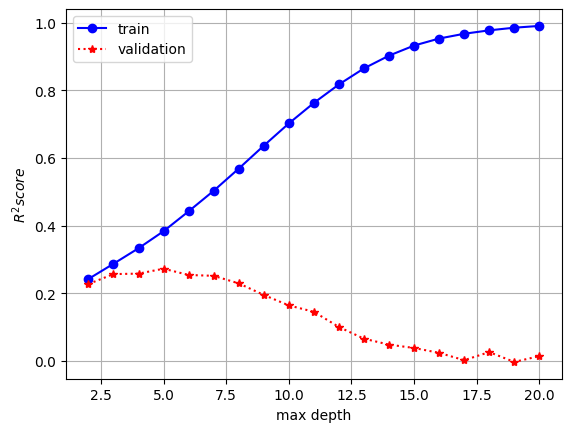

In [384]:
plt.plot(max_depths, train_scores,'bo-',label='train')
plt.plot(max_depths,val_scores,'r*:',label='validation')
plt.xlabel('max depth')
plt.ylabel(r'$R^2score$')
plt.grid()
plt.legend()
plt.show()

In [390]:
np.argmax(val_scores)

np.int64(3)

In [389]:
max_depths[np.argmax(val_scores)] # 테스트 스코어(검증 셋 점수)가 가장 좋은 max_depth

np.int64(5)

In [392]:
val_scores[np.argmax(val_scores)] # 가장 좋은 테스트 점수

np.float64(0.2728187073512451)

In [355]:
# cv=cross_validate(tree_reg,x_tr_full,y_tr_full,cv=5,n_jobs=-1,return_train_score=True)
train=[]
test=[]
# std=[]
depth=np.arange(2,16)
for d in depth:
  clf=DecisionTreeRegressor(max_depth=d,random_state=42)
  cv=cross_validate(clf,x_tr_full,y_tr_full,cv=5,n_jobs=-1,return_train_score=True)
  train.append(np.mean(cv['train_score'])) # 5-ford cv에서 5개의 훈련 점수들의 평균으로 측정
  test.append(np.mean(cv['test_score'])) # 5-ford cv에서 5개의 검증 점수들의 평균
  # std.append(np.std(cv['test_score']))


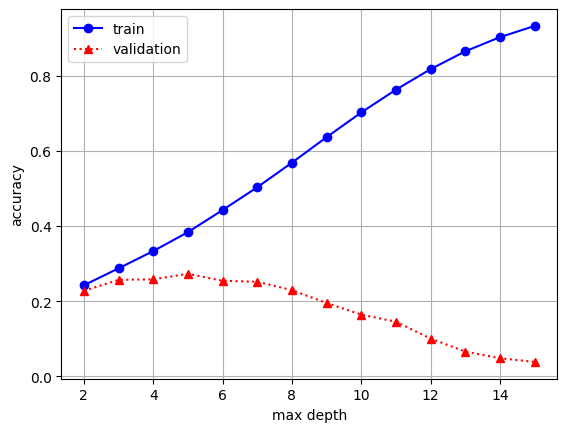

In [356]:
plt.plot(depth,train, 'bo-',label='train')
plt.plot(depth,test,'r^:',label='validation')
# plt.plot(depth,std)
plt.legend()
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.grid()
plt.show()

In [376]:
crossv=cross_val_score(estimator=tree_reg,X=x_tr_full,y=y_tr_full,cv=5,n_jobs=-1)
crossv

array([-3.87674644e-02,  1.33365344e-01, -3.70307924e-02,  4.18716634e-05,
       -2.56635591e-02])

## `GridSearchCV` 사용한 최적의 max_depth, min_samples_split, max_features 찾기

In [391]:
tree_reg=DecisionTreeRegressor(random_state=42)
params={
    'max_depth':np.arange(2,21),
    'min_samples_split':np.arange(2,101,2),
    'max_features':np.arange(1,12)
}
grid_cv=GridSearchCV(tree_reg,params,n_jobs=-1)
grid_cv.fit(x_tr_full,y_tr_full)


GridSearchCV(estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20]),
                         'max_features': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
                         'min_samples_split': array([  2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,  26,
        28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,  52,
        54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,  78,
        80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100])})

In [399]:
grid_cv.best_score_

np.float64(0.3131239209271538)

In [398]:
grid_cv.best_params_

{'max_depth': np.int64(7),
 'max_features': np.int64(8),
 'min_samples_split': np.int64(38)}

In [396]:
grid_cv.best_estimator_

DecisionTreeRegressor(max_depth=np.int64(7), max_features=np.int64(8),
                      min_samples_split=np.int64(38), random_state=42)

In [357]:
clf=DecisionTreeRegressor(random_state=42)

In [365]:
params = {
    'max_depth':np.arange(2,11),
    'min_samples_split': [2,5,10,20,30],
    'max_features':[None,'sqrt','log2']
}

In [366]:
gridcv=GridSearchCV(clf,param_grid=params,n_jobs=-1)

In [367]:
gridcv.fit(x_tr_full,y_tr_full)

GridSearchCV(estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_split': [2, 5, 10, 20, 30]})

In [368]:
gridcv.best_estimator_

DecisionTreeRegressor(max_depth=np.int64(5), min_samples_split=20,
                      random_state=42)

np.int64(48)

In [370]:
gridcv.best_params_

{'max_depth': np.int64(5), 'max_features': None, 'min_samples_split': 20}

In [371]:
gridcv.best_score_

np.float64(0.27884408984003123)

# Pipeline과 GridSearch CV

* PolynomialFeatures, StandardScaler, LinearRegression/ElasticNet을 Pipeline으로 연결
* GridSearchCV를 사용해서 하이퍼 파라미터들을 튜닝
  * PolynomialFeatures = degree
  * ElasticNet = alpha, l1_ratio

In [400]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.pipeline import Pipeline

## LinearRegression

In [401]:
model_1 = Pipeline(steps=[('poly',PolynomialFeatures(include_bias=False)),('scaler',StandardScaler()),('reg',LinearRegression())])

In [402]:
params={
    'poly__degree':np.arange(1,6),

}# steps의 키값에 (__ 두개 주기) 파라미터이름

In [403]:
grid_cv=GridSearchCV(model_1,params,n_jobs=-1)

In [404]:
grid_cv.fit(x_tr_full,y_tr_full)

GridSearchCV(estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('reg', LinearRegression())]),
             n_jobs=-1, param_grid={'poly__degree': array([1, 2, 3, 4, 5])})

In [405]:
grid_cv.best_score_

np.float64(0.3431826785315675)

In [406]:
grid_cv.best_params_

{'poly__degree': np.int64(2)}

## ElasticNet

In [407]:
model_2 =Pipeline(steps=[('poly',PolynomialFeatures(include_bias=False)),('scaler',StandardScaler()),('reg',ElasticNet(random_state=42))])

In [408]:
params={
    'poly__degree':[1,2,3],
    'reg__alpha':[10**x for x in range(-4,2)], # l1, l2 규제의 크기 숫자가 클수록 규제가 크다
    'reg__l1_ratio': np.arange(0.1, 1.0, 0.1) # l1 규제의 비율
}

In [409]:
grid_cv=GridSearchCV(model_2,params,n_jobs=-1)

In [410]:
grid_cv.fit(x_tr_full,y_tr_full)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.451e+01, tolerance: 3.081e-01
  model = cd_fast.enet_coordinate_descent(


GridSearchCV(estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('reg', ElasticNet(random_state=42))]),
             n_jobs=-1,
             param_grid={'poly__degree': [1, 2, 3],
                         'reg__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
                         'reg__l1_ratio': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])})

In [411]:
grid_cv.best_score_

np.float64(0.3408732617512554)

In [412]:
grid_cv.best_params_

{'poly__degree': 3, 'reg__alpha': 0.01, 'reg__l1_ratio': np.float64(0.1)}